# Canadian Tech Roles: Volume, Trajectory & Market Demand (2023–2026)

This notebook analyzes monthly microdata from **Job Bank Canada Open Data** across **43 monthly snapshots** (January 2023 to July 2026).

### Core Objective:
Track the hiring volume and trajectory across Canada's core **National Occupational Classification (NOC 2021)** tech roles:
1. **21232**: Software developers and programmers
2. **21222**: Information systems specialists
3. **21231**: Software engineers and designers
4. **21223**: Database analysts and data administrators
5. **21234**: Web developers and programmers
6. **21221**: Business systems specialists
7. **21220**: Cybersecurity specialists
8. **21211**: Data scientists
9. **21230**: Computer systems developers and programmers
10. **21311**: Computer engineers (except software engineers)

In [1]:
%matplotlib inline
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6.5)
plt.rcParams['font.size'] = 11

# Path resolution
cwd = Path.cwd()
if (cwd / 'data/job_bank').exists():
    DATA_DIR = cwd / 'data/job_bank'
    PLOTS_DIR = cwd / 'data_analysis/02_job_bank/plots'
elif (cwd / '../../data/job_bank').resolve().exists():
    DATA_DIR = (cwd / '../../data/job_bank').resolve()
    PLOTS_DIR = cwd / 'plots'
else:
    DATA_DIR = Path('data/job_bank')
    PLOTS_DIR = Path('plots')

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data Directory:  {DATA_DIR}")
print(f"Plots Directory: {PLOTS_DIR}")

## 1. Define Target Tech NOC 2021 Roles & Smart Data Loader

The Job Bank catalogue contains 43 monthly files:
- **39 files** are encoded in `UTF-16` with **tab (`\t`)** delimiters.
- **4 files** (summer 2024) are encoded in `UTF-8` with **comma (`,`)** delimiters.

Our loader auto-detects the byte-order mark (BOM) and delimiter for seamless processing.

In [2]:
TARGET_NOCS = {
    '21232': 'Software Developers & Programmers',
    '21222': 'Information Systems Specialists',
    '21231': 'Software Engineers & Designers',
    '21223': 'Database Analysts & Data Admins',
    '21234': 'Web Developers & Programmers',
    '21221': 'Business Systems Specialists',
    '21220': 'Cybersecurity Specialists',
    '21211': 'Data Scientists',
    '21230': 'Computer Systems Developers',
    '21311': 'Computer Engineers (non-software)'
}

def read_job_bank_csv(file_path, usecols):
    with open(file_path, 'rb') as f:
        raw_start = f.read(512)
    if raw_start.startswith(b'\xff\xfe') or raw_start.startswith(b'\xfe\xff'):
        enc = 'utf-16'
        sep = '\t'
    else:
        enc = 'utf-8'
        sep = ','
    try:
        return pd.read_csv(file_path, sep=sep, encoding=enc, usecols=usecols, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(file_path, sep=sep, encoding='latin1', usecols=usecols, low_memory=False)

def parse_file_month(p):
    name = p.stem.lower()
    months = {
        'jan': 1, 'january': 1, 'feb': 2, 'february': 2, 'mar': 3, 'march': 3,
        'apr': 4, 'april': 4, 'may': 5, 'jun': 6, 'june': 6, 'jul': 7, 'july': 7,
        'aug': 8, 'august': 8, 'sep': 9, 'september': 9, 'oct': 10, 'october': 10,
        'nov': 11, 'november': 11, 'dec': 12, 'december': 12
    }
    match = re.search(r'([a-z]+)(\d{4})', name)
    if match:
        m_str, y_str = match.groups()
        for k, v in months.items():
            if m_str.endswith(k) or m_str == k:
                return pd.Period(f"{y_str}-{v:02d}", freq='M')
    return None

print("Loader configured for", len(TARGET_NOCS), "technical roles.")

## 2. Extract and Aggregate Tech Postings Across All 43 Months

In [3]:
files = sorted(DATA_DIR.glob('*.csv'))
print(f"Processing {len(files)} monthly Job Bank files...")

monthly_records = []
for f in files:
    period = parse_file_month(f)
    if not period:
        continue
    cols = ['NOC21 Code', 'Vacancy Count']
    df_month = read_job_bank_csv(f, usecols=cols)
    df_month['NOC_clean'] = df_month['NOC21 Code'].astype(str).str.replace(r'\.0$', '', regex=True)
    
    # Filter for target tech occupations
    tech_sub = df_month[df_month['NOC_clean'].isin(TARGET_NOCS.keys())].copy()
    tech_sub['Period'] = period
    tech_sub['Role'] = tech_sub['NOC_clean'].map(TARGET_NOCS)
    
    agg = tech_sub.groupby(['Period', 'Role']).agg(
        Postings=('NOC_clean', 'count'),
        Vacancies=('Vacancy Count', 'sum')
    ).reset_index()
    monthly_records.append(agg)

df_tech_all = pd.concat(monthly_records, ignore_index=True)
pivot_postings = df_tech_all.pivot(index='Period', columns='Role', values='Postings').fillna(0)
pivot_postings.index = pivot_postings.index.to_timestamp()

print(f"Extraction complete: {len(pivot_postings)} monthly periods from {pivot_postings.index.min().strftime('%b %Y')} to {pivot_postings.index.max().strftime('%b %Y')}.")
pivot_postings.tail()

## 3. Monthly Trajectory Over Time (2023–2026)

Tracking how monthly active postings for each role evolved over the 43-month timeline.

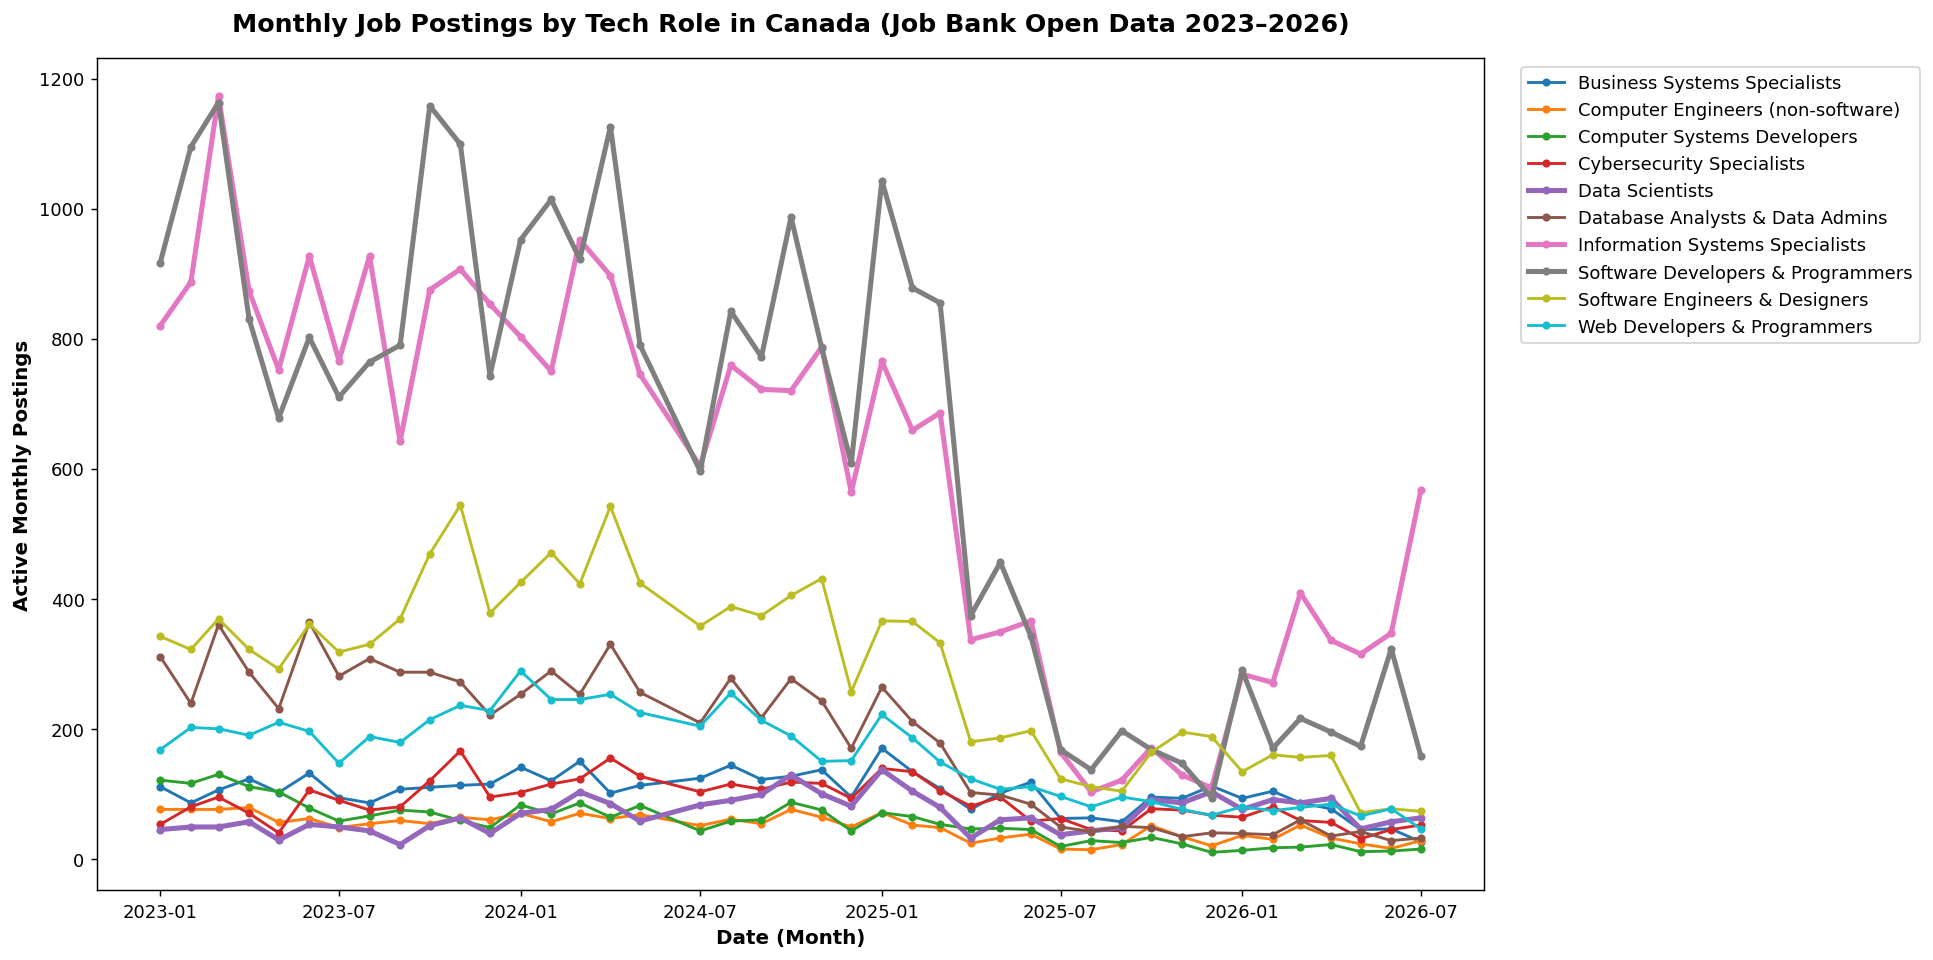

In [4]:
fig1, ax = plt.subplots(figsize=(15, 7.5))
colors = sns.color_palette('tab10', len(TARGET_NOCS))

for i, role in enumerate(pivot_postings.columns):
    lw = 2.8 if role in ['Software Developers & Programmers', 'Information Systems Specialists', 'Data Scientists'] else 1.6
    ax.plot(pivot_postings.index, pivot_postings[role], label=role, linewidth=lw, marker='o', markersize=3.5, color=colors[i])

ax.set_title('Monthly Job Postings by Tech Role in Canada (Job Bank Open Data 2023–2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date (Month)', fontsize=11, fontweight='bold')
ax.set_ylabel('Active Monthly Postings', fontsize=11, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig(PLOTS_DIR / 'job_bank_tech_roles_trajectory.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Market Size vs. Growth Trajectory (2023 vs. 2026)

Comparing cumulative volume against the percentage change from 2023 to 2026.

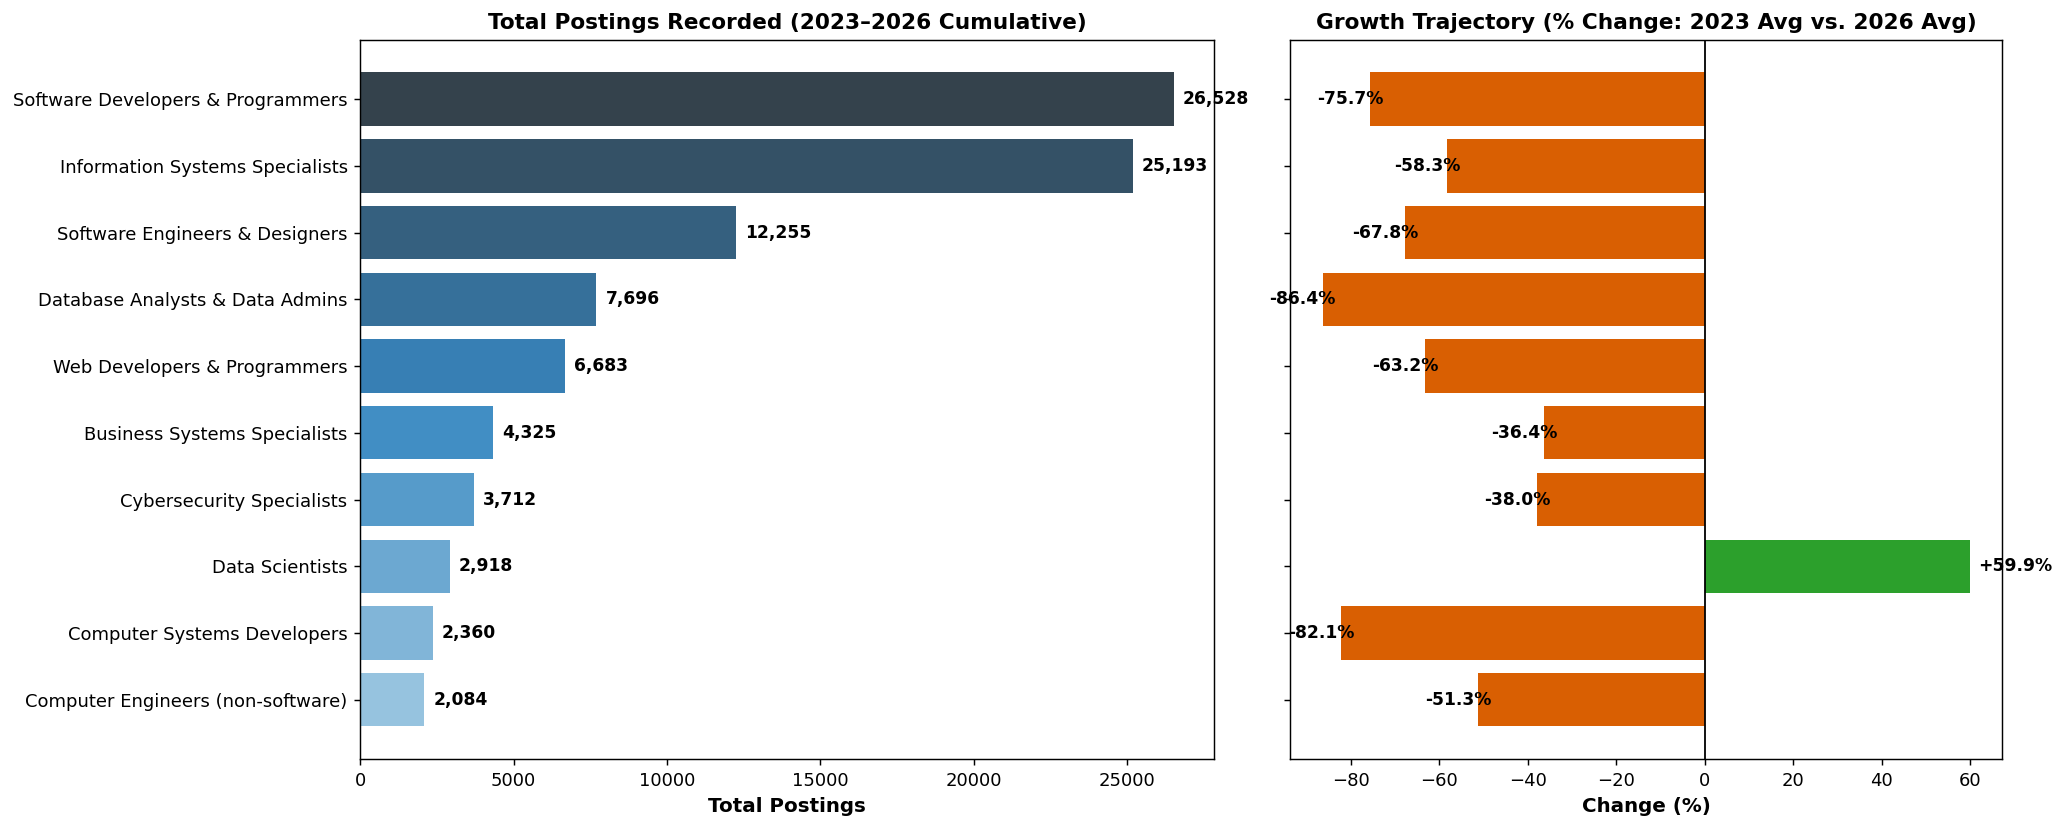

In [5]:
totals = pivot_postings.sum().sort_values(ascending=True)
df_2023 = pivot_postings[pivot_postings.index.year == 2023].mean()
df_2026 = pivot_postings[pivot_postings.index.year == 2026].mean()
growth = (((df_2026 - df_2023) / df_2023) * 100).loc[totals.index]

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={'width_ratios': [1.2, 1]})

# Panel 1: Total Market Volume
palette1 = sns.color_palette('Blues_d', len(totals))
bars1 = ax1.barh(totals.index, totals.values, color=palette1)
ax1.set_title('Total Postings Recorded (2023–2026 Cumulative)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Postings', fontsize=11, fontweight='bold')
for b in bars1:
    w = b.get_width()
    ax1.text(w + 300, b.get_y() + b.get_height()/2, f"{int(w):,}", va='center', fontsize=9.5, fontweight='bold')

# Panel 2: Growth Trajectory
colors2 = ['#2ca02c' if g > 0 else '#d95f02' for g in growth]
bars2 = ax2.barh(growth.index, growth.values, color=colors2)
ax2.axvline(0, color='black', linewidth=1)
ax2.set_title('Growth Trajectory (% Change: 2023 Avg vs. 2026 Avg)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Change (%)', fontsize=11, fontweight='bold')
ax2.set_yticklabels([])
for b in bars2:
    w = b.get_width()
    offset = 2 if w >= 0 else -12
    ax2.text(w + offset, b.get_y() + b.get_height()/2, f"{w:+.1f}%", va='center', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'job_bank_tech_roles_volume_growth.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Strategic Ranking: Best Tech Roles to Target

A combined overview of monthly volume, growth trajectory, and cumulative postings across Canada.

In [6]:
summary_table = pd.DataFrame({
    '2023 Monthly Avg': df_2023.round(1),
    '2026 Monthly Avg': df_2026.round(1),
    'Change (%)': growth.round(1),
    'Total Postings (43 mo)': totals
}).sort_values(by='2026 Monthly Avg', ascending=False)

summary_table.reset_index()

## 6. Key Takeaways for Job Seekers

1. **Information Systems Specialists (NOC 21222) is Currently #1**:
   - In 2026, it averages **361 active postings per month**, surpassing pure Software Developers (218/month).
   - This role encompasses cloud systems, IT architecture, solutions engineering, and system integration.

2. **Data Scientists (NOC 21211) is the Only Role Showing Strong Net Growth (+59.9%)**:
   - Rose from **45.8 postings/month in 2023** to **73.1 postings/month in 2026**.
   - Reflects the rapid expansion of corporate AI and predictive modeling initiatives.

3. **Software Developers (NOC 21232) has the Highest Cumulative Volume but Deepest Compression**:
   - Still holds the highest total cumulative postings (**26,528**), but contracted **-75.7%** from early 2023 peaks, meaning high applicant competition per role.